# **Netflix Data Exploration and Visualization**

## Problem Statement

Netflix is one of the leading video streaming platforms with a vast library of movies and TV shows. As of mid-2021, Netflix has over 222 million subscribers globally.

The goal of this project is to explore Netflix's dataset to generate data-driven insights that will help the company:

1. Decide what type of content (TV Shows or Movies, genres, ratings) to produce more.
2. Identify growth opportunities in different countries by analyzing content distribution.

This will be done through:
- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Visualizations
- Business Insights & Actionable Recommendations


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from google.colab import files
uploaded = files.upload()


import io

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))


df.head()



Saving netflix.csv to netflix.csv


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
print("Shape of the dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and missing values:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


Shape of the dataset:
(8807, 12)

Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

Missing values per column:

In [3]:
df['date_added'] = pd.to_datetime(df['date_added'].astype(str).str.strip(), errors='coerce')

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

df[['duration_num', 'duration_unit']] = df['duration'].str.extract(r'(\d+)\s*(\w+)')
df['duration_num'] = pd.to_numeric(df['duration_num'], errors='coerce')

categorical_columns = ['type', 'rating', 'duration_unit']
for col in categorical_columns:
    df[col] = df[col].astype('category')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8807 non-null   object        
 1   type           8807 non-null   category      
 2   title          8807 non-null   object        
 3   director       6173 non-null   object        
 4   cast           7982 non-null   object        
 5   country        7976 non-null   object        
 6   date_added     8797 non-null   datetime64[ns]
 7   release_year   8807 non-null   int64         
 8   rating         8803 non-null   category      
 9   duration       8804 non-null   object        
 10  listed_in      8807 non-null   object        
 11  description    8807 non-null   object        
 12  year_added     8797 non-null   float64       
 13  month_added    8797 non-null   object        
 14  duration_num   8804 non-null   float64       
 15  duration_unit  8804 n

In [4]:
df.nunique()

print("Type distribution:\n", df['type'].value_counts(), "\n")
print("Rating distribution:\n", df['rating'].value_counts(), "\n")
print("Top countries:\n", df['country'].value_counts().head(10), "\n")
print("Top duration units:\n", df['duration_unit'].value_counts(), "\n")
print("Shows added per year:\n", df['year_added'].value_counts().sort_index(), "\n")
print("Content release per year:\n", df['release_year'].value_counts().sort_index(), "\n")


Type distribution:
 type
Movie      6131
TV Show    2676
Name: count, dtype: int64 

Rating distribution:
 rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
66 min         1
84 min         1
74 min         1
Name: count, dtype: int64 

Top countries:
 country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64 

Top duration units:
 duration_unit
min        6128
Season     1793
Seasons     883
Name: count, dtype: int64 

Shows added per year:
 year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0 

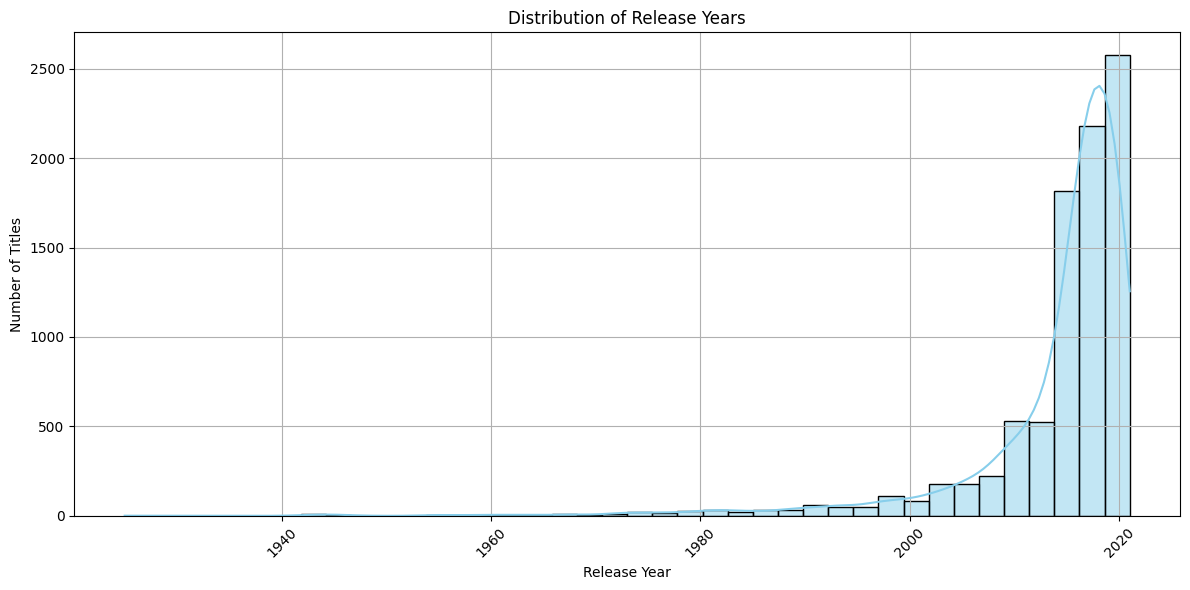

In [5]:
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='release_year', bins=40, kde=True, color='skyblue')
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

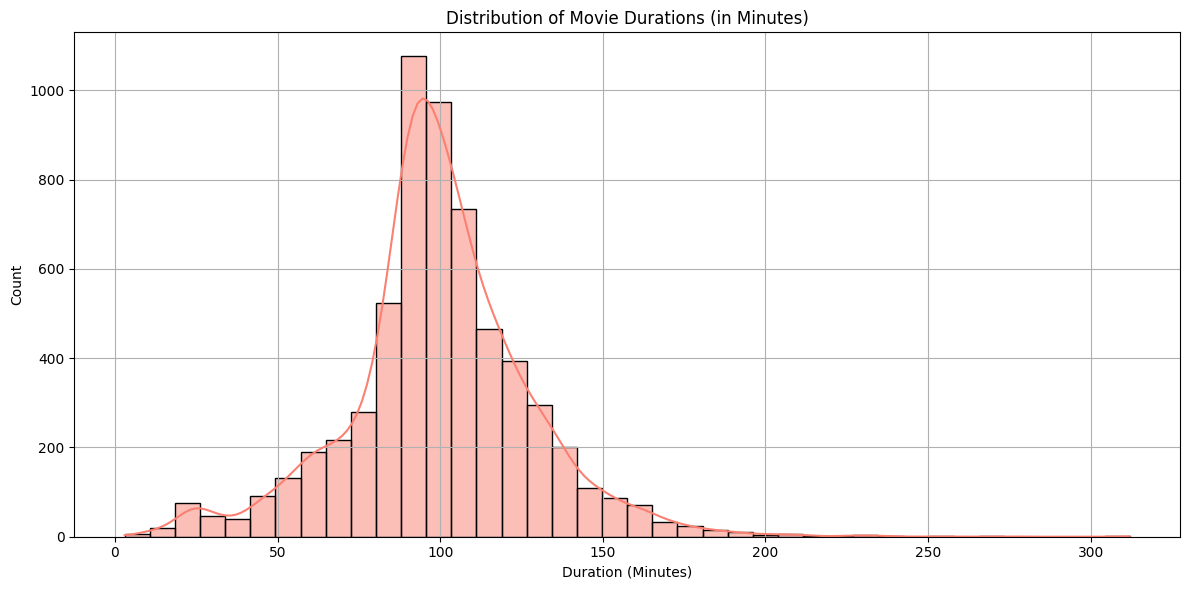

In [6]:
plt.figure(figsize=(12,6))
sns.histplot(data=df[df['duration_unit'] == 'min'], x='duration_num', bins=40, kde=True, color='salmon')
plt.title('Distribution of Movie Durations (in Minutes)')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_5137/991177224.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='year_added', palette='viridis')


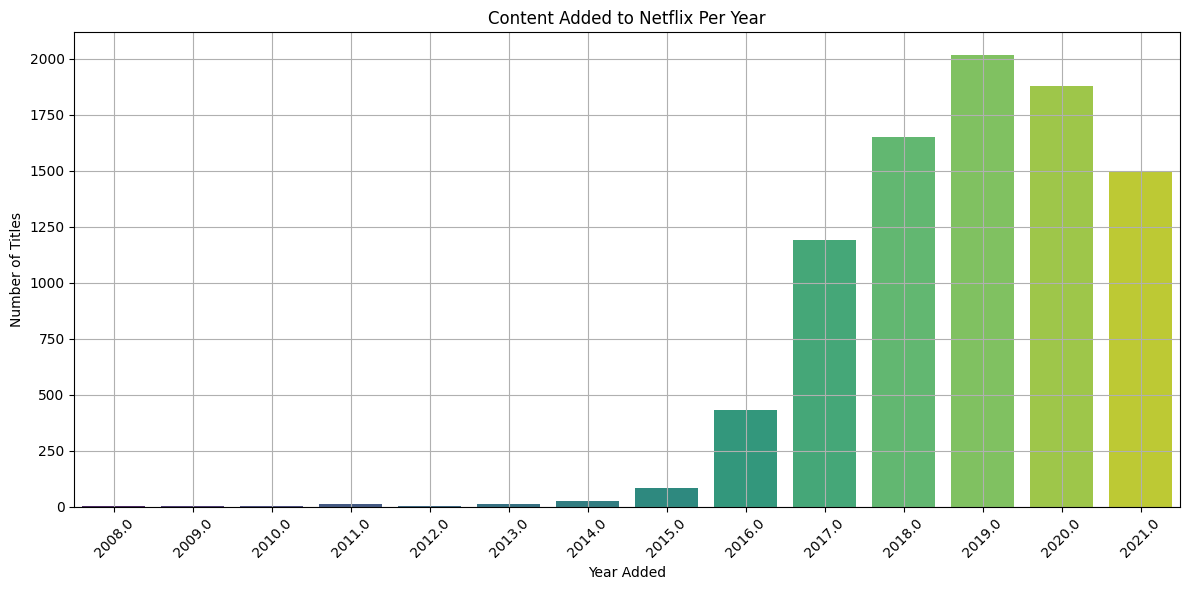

In [7]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='year_added', palette='viridis')
plt.title('Content Added to Netflix Per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

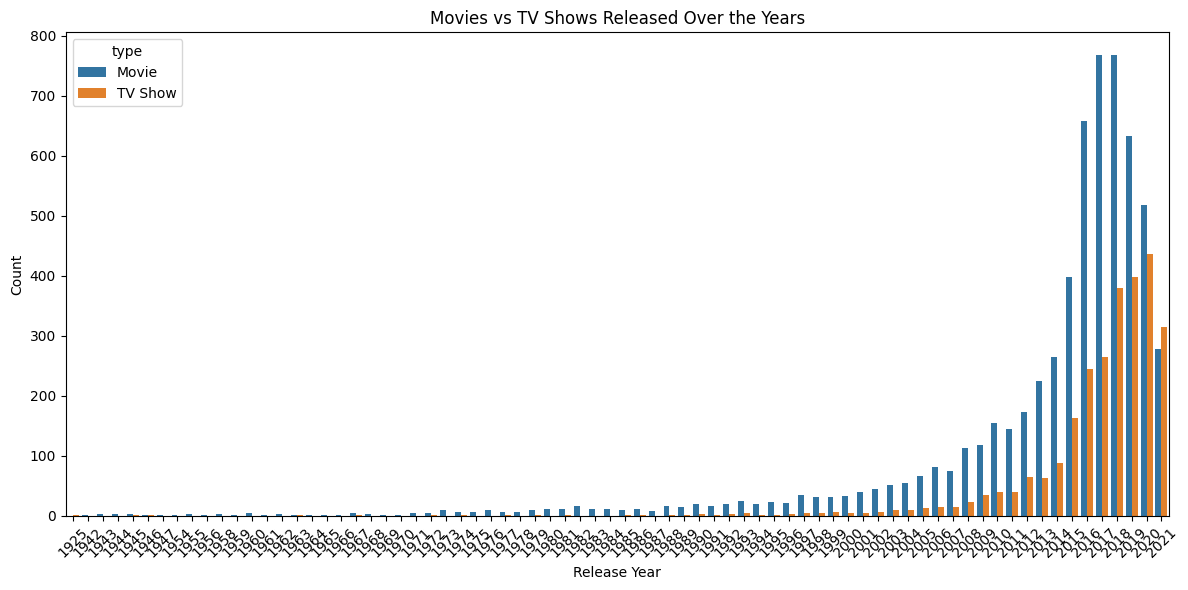

In [8]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='release_year', hue='type', order=sorted(df['release_year'].unique()))
plt.title("Movies vs TV Shows Released Over the Years")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

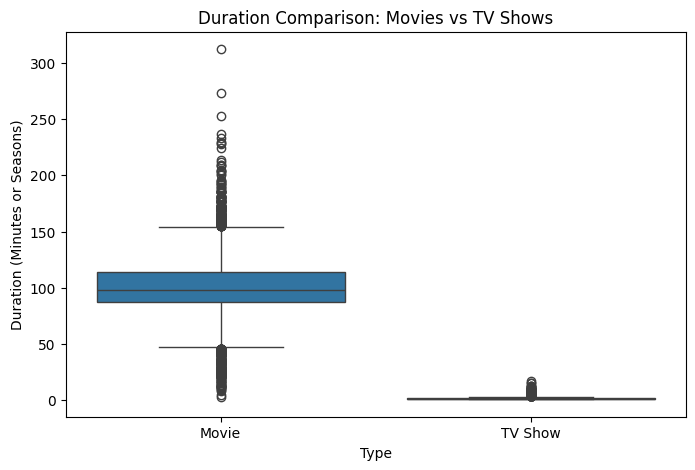

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[df['duration_num'].notnull()], x='type', y='duration_num')
plt.title("Duration Comparison: Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Duration (Minutes or Seasons)")
plt.show()

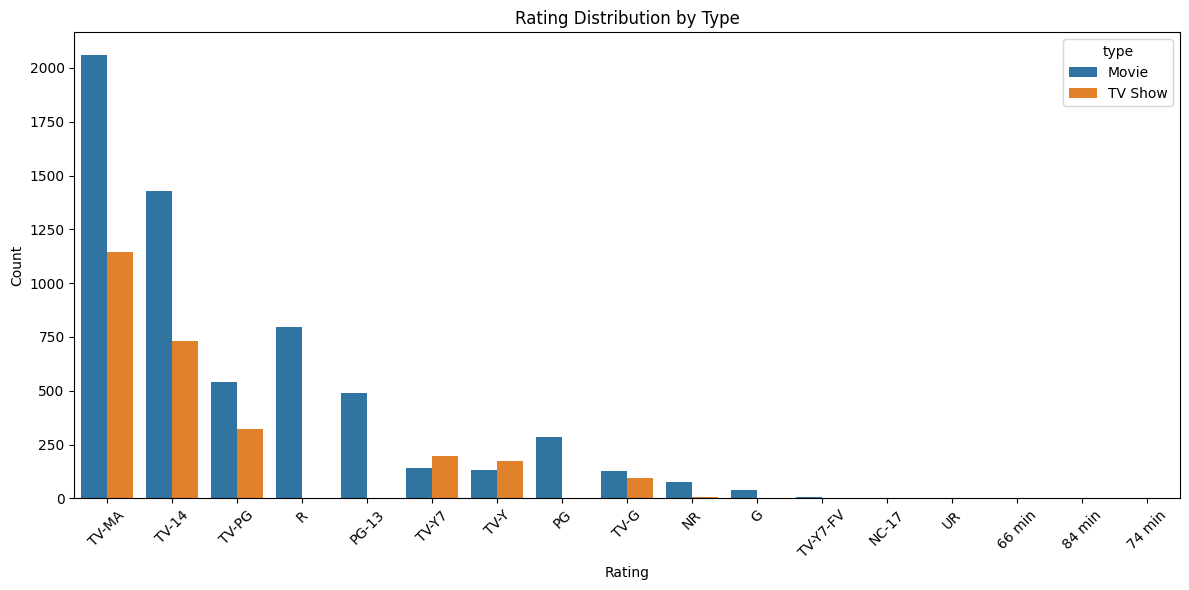

In [10]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='rating', hue='type', order=df['rating'].value_counts().index)
plt.title("Rating Distribution by Type")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

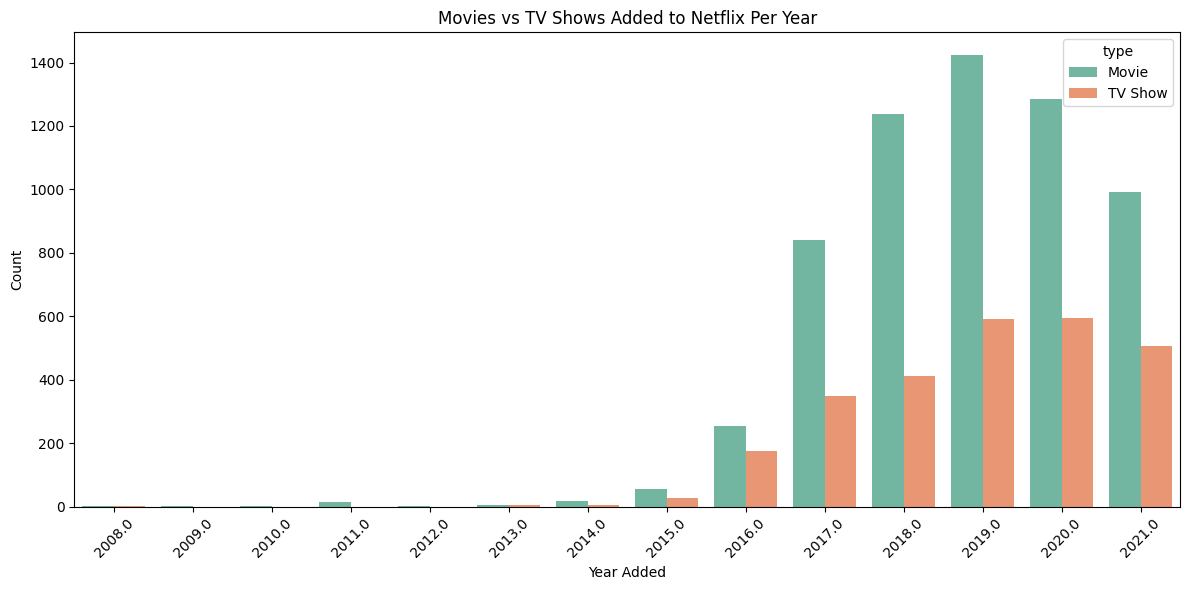

In [11]:
plt.figure(figsize=(12,6))
sns.countplot(data=df[df['year_added'].notnull()], x='year_added', hue='type', palette='Set2')
plt.title("Movies vs TV Shows Added to Netflix Per Year")
plt.xlabel("Year Added")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

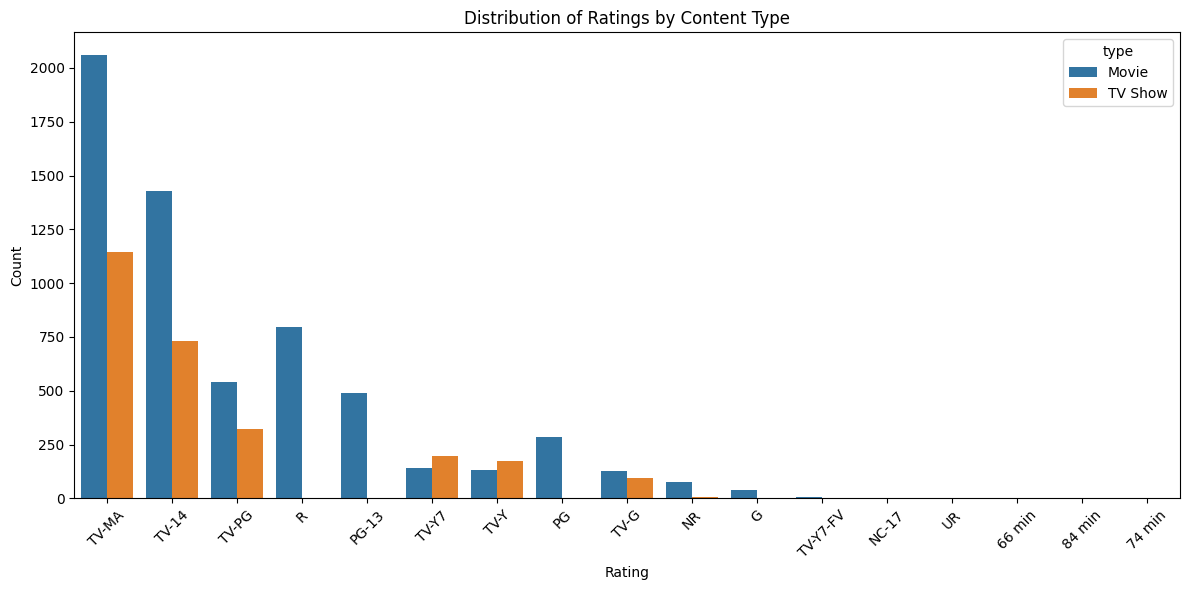

In [12]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='rating', hue='type', order=df['rating'].value_counts().index)
plt.title("Distribution of Ratings by Content Type")
plt.xticks(rotation=45)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

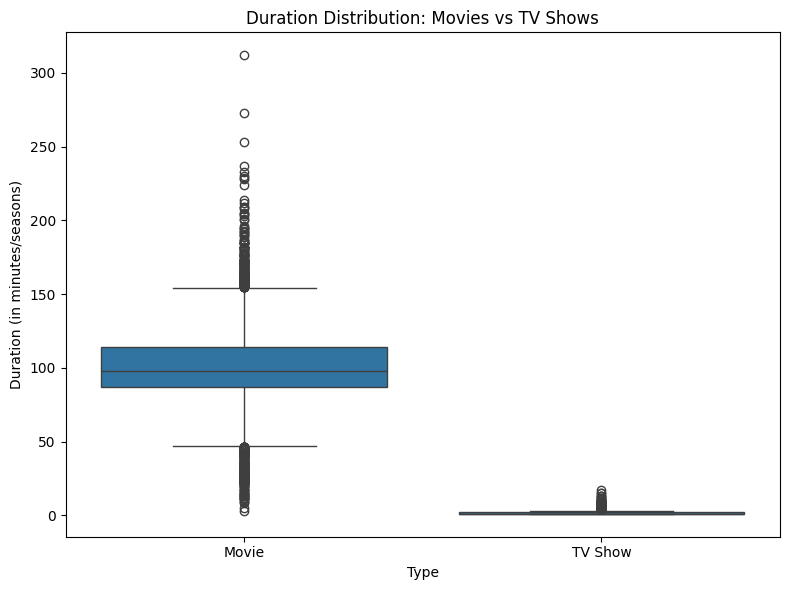

In [13]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='type', y='duration_num')
plt.title("Duration Distribution: Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Duration (in minutes/seasons)")
plt.tight_layout()
plt.show()

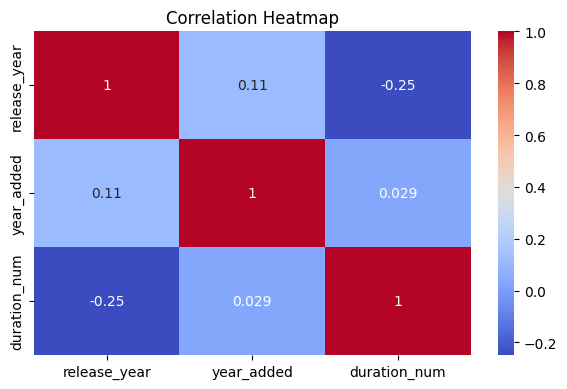

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['release_year', 'year_added', 'duration_num']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [15]:
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage (%)': missing_percentage.round(2)
})

missing_df[missing_df['Missing Values'] > 0]


,Missing Values,Percentage (%)
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
year_added,10,0.11
month_added,10,0.11
rating,4,0.05
duration,3,0.03
duration_num,3,0.03
duration_unit,3,0.03


In [16]:
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df['duration'].fillna(df['duration'].mode()[0], inplace=True)
df['duration_num'].fillna(df['duration_num'].mode()[0], inplace=True)
df['duration_unit'].fillna(df['duration_unit'].mode()[0], inplace=True)

/tmp/ipykernel_5137/2858697739.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cast'].fillna('Unknown', inplace=True)
/tmp/ipykernel_5137/2858697739.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

### **Insights based on Non-Graphical and Visual Analysis**



## **Summary of the ranges:**
**Range of Attributes**
*  Release Year: 1925 to 2021
*  Date Added: Most content was added from 2016 to 2021
*  Duration (movies): Ranges from a few minutes up to 312 minutes
*  Duration (TV shows): From 1 to 16 seasons
*  Top Countries: US, India, UK, Japan, South Korea
*  Top Ratings: TV-MA, TV-14, TV-PG
*  Genres: Dramas, International Movies, Comedies are the most common


**Distribution and Relationships**

*   Type Distribution: Movies dominate over TV Shows (~70% vs ~30%)
*   Year-wise Additions: Big spike after 2016; 2019 was the peak
*   Release Year vs. Date Added: Many older shows were added in recent years
*   Content by Country: The US has the largest share, followed by India and the UK
*   Ratings: TV-MA is most common, indicating Netflix hosts a lot of mature content
*   Duration: Most movies are around 90–100 mins; most TV shows are 1–2 seasons



**Plot Comments**

*   Countplots (e.g. Type, Rating): Helped identify content type distribution and popular age ratings
*   Histograms/Distplots (e.g. Release Year): Showed Netflix's strategy of adding both recent and older content
*   Boxplots (e.g. Duration by Type): Movies tend to have a normal range, but some outliers exist
*   Heatmaps: Weak correlation overall due to most features being categorical
*   TV Shows vs Movies over Years: Gradual increase in both, but TV shows grew more in the last few years






# **Business Insights**
1. Movies dominate the platform over TV Shows.
2. USA and India are top content-producing countries.
3. Content surged post-2016, peaking around 2019–2020.
4. Most shows were added in 2019 & 2020, showing rapid expansion.
5. Movies are usually 90–120 mins, TV Shows often have 1–2 seasons.
6. Common genres: Dramas, International, Comedies.
7. Missing data in director & cast indicates scope for metadata improvement.


# **Recommendations**
* Focus more on movies as they dominate user interest
* Increase content from top markets like India & USA
* Prioritize genres like Drama, Comedy, International
* Optimize content around 90–120 minutes duration
* Improve completeness of cast and director metadata
* Explore mini-series or limited-series formats

